<a href="https://colab.research.google.com/github/Rishabh2004580/Heart-desease/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
file_path = "/content/data.csv"
data = pd.read_csv(file_path)

In [30]:

print("Columns in dataset:", data.columns.tolist(), "\n")

Columns in dataset: ['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city', 'statezip', 'country'] 



In [31]:
possible_targets = ['Price', 'price', 'MEDV', 'HousePrice', 'house_price']
target_column = None
for col in data.columns:
    if col in possible_targets:
        target_column = col
        break

In [32]:
if target_column is None:
    print("❌ Could not detect target column automatically.")
    print("Please choose from:", data.columns.tolist())
else:
    print(f"✅ Using target column: {target_column}")

✅ Using target column: price


In [33]:
if target_column:
    # Keep only numeric columns
    numeric_df = data.select_dtypes(include=[np.number])

In [34]:
    if target_column not in numeric_df.columns:
        numeric_df[target_column] = data[target_column]


In [36]:
  X = numeric_df.drop(target_column, axis=1)
  y = numeric_df[target_column]

In [37]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
    y_pred = model.predict(X_test)

In [41]:
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

In [42]:
 print("\n📊 Model Performance:")
 print(f"RMSE: {rmse}")
 print(f"R² Score: {r2}")


📊 Model Performance:
RMSE: 993439.3625461488
R² Score: 0.032283856632802865


In [45]:
 comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
 print("\nSample Predictions:")
 print(comparison_df.head())


Sample Predictions:
         Actual     Predicted
3683   544000.0  3.048634e+05
4411        0.0  3.265171e+05
2584  1712500.0  1.071763e+06
69     365000.0  5.462414e+05
1844   275000.0  3.798000e+05


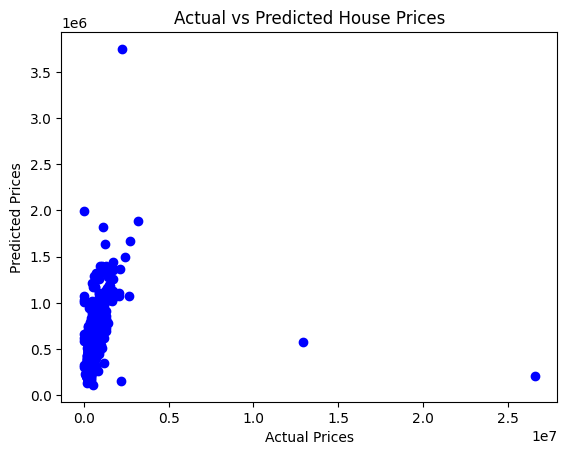

In [47]:
    plt.scatter(y_test, y_pred, color='blue')
    plt.xlabel("Actual Prices")
    plt.ylabel("Predicted Prices")
    plt.title("Actual vs Predicted House Prices")
    plt.show()